# Klasifikasi Sawah vs Non-Sawah Menggunakan Sentinel-2A dan Random Forest

Notebook ini mengklasifikasikan tutupan lahan menjadi **dua kelas** (sawah dan non-sawah) dari citra satelit **Sentinel-2A Level-2A** yang diunduh otomatis dari **Copernicus Data Space** dalam format **GeoTIFF**. Model yang dipakai adalah **Random Forest** (scikit-learn), dan hasil akhirnya berupa peta klasifikasi `klasifikasi_sawah_s2a.tif`.

## Ketentuan tugas dan pemenuhannya

| Ketentuan tugas | Pemenuhan di notebook ini |
|---|---|
| 50 sampel sawah | 50 poligon dari `sawah.shp` (kelas 1) |
| 50 sampel non-sawah | 50 poligon dari `nonsawah.shp` (kelas 0) |
| Klasifikasi 2 kelas | Kelas 1 = sawah, kelas 0 = non-sawah |
| Data Sentinel-2A (TIF) | Sentinel-2A L2A, diunduh sebagai GeoTIFF 6 band, resolusi 10 m |

## Alur kerja

1. Mengatur parameter
2. Membaca sampel poligon (shapefile) dan menentukan area unduhan
3. Mengunduh citra Sentinel-2A dari Copernicus
4. Membaca citra GeoTIFF
5. Menghitung fitur: band + indeks spektral (NDVI, NDWI, NDBI, EVI)
6. Rasterisasi poligon sampel menjadi piksel berlabel
7. Membagi data training dan testing per poligon
8. Melatih dan mengevaluasi model
9. Mengklasifikasikan seluruh citra
10. Menyimpan GeoTIFF dan membuat peta hasil

## 0. Persiapan

**Library** yang dibutuhkan:

```bash
pip install requests rasterio scikit-learn numpy matplotlib geopandas
```

**Akun Copernicus (sekali saja):**

1. Buka <https://shapps.dataspace.copernicus.eu/dashboard> dan login.
2. Masuk ke *User settings → OAuth clients → Create*, lalu salin **Client ID** dan **Client Secret**.
3. Masukkan keduanya lewat *environment variable* `CDSE_CLIENT_ID` dan `CDSE_CLIENT_SECRET`, atau ketik saat notebook memintanya.

> **Penting:** jangan menulis Client Secret langsung di dalam notebook atau repository. Notebook yang dipublikasikan ke web statis bisa dibaca siapa saja.

**Struktur folder** (di folder yang sama dengan notebook):

```
klasifikasi_sawah/
├── klasifikasi_sawah.ipynb
├── datasawah50/   →  sawah.shp (+ .dbf .shx .prj)
└── nonsawah/      →  nonsawah.shp (+ .dbf .shx .prj)
```

In [1]:
# Hapus tanda # di baris berikut jika library belum terpasang
# %pip install requests rasterio scikit-learn numpy matplotlib geopandas

## 1. Import library dan parameter

Library yang dipakai dan fungsinya:

- **geopandas / shapely / rasterio**: membaca shapefile, mengubah proyeksi, merasterisasi poligon, membaca dan menulis GeoTIFF
- **requests**: berkomunikasi dengan API Copernicus (token, katalog, unduhan)
- **numpy**: operasi array citra
- **scikit-learn**: Random Forest dan metrik evaluasi
- **matplotlib**: visualisasi

Semua pengaturan dikumpulkan di satu sel agar mudah diubah.

In [2]:
import datetime as dt
import getpass
import math
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import requests
from matplotlib.colors import ListedColormap
from rasterio import features
from rasterio.warp import transform_bounds, transform_geom
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             cohen_kappa_score, confusion_matrix)

BASE_DIR = Path.cwd()

In [3]:
# --- Pencarian citra ---
START_DATE = "2026-06-01"      # rentang tanggal pencarian citra
END_DATE = "2026-09-30"
PLATFORM_PREFIX = "S2A"        # hanya Sentinel-2A. Isi None untuk semua satelit Sentinel-2
MAX_CLOUD = 30                 # % awan maksimum (level tile) untuk kandidat scene
MAX_TRIES = 5                  # coba maks. N scene terbaik sampai area sampel cukup bersih
MIN_VALID = 0.90               # minimal fraksi piksel bebas awan di area unduhan
MASK_CLOUD = True              # buang awan/bayangan awan/salju memakai band SCL
BUFFER_M = 1500                # margin area unduhan di sekeliling sampel (meter)

# --- Sampel & model ---
N_SAMPLE = 50                  # jumlah poligon sampel PER KELAS
FILE_SAWAH    = BASE_DIR / "datasawah50" / "sawah.shp"      # kelas = 1
FILE_NONSAWAH = BASE_DIR / "nonsawah"    / "nonsawah.shp"   # kelas = 0
TRAIN_FRAC = 0.7               # porsi poligon untuk training (sisanya testing)
N_TREES = 200
SEED = 42

# --- File ---
# Jika file ini sudah ada, unduhan dilewati (boleh juga diisi TIF manual dari
# Copernicus Browser dengan band B02,B03,B04,B08,B11,B12 berurutan).
TIF_IN = BASE_DIR / "sentinel2a_aoi.tif"
INFO_TXT = BASE_DIR / "sentinel2a_aoi_info.txt"
OUT_TIF = BASE_DIR / "klasifikasi_sawah_s2a.tif"
OUT_PNG = BASE_DIR / "peta_klasifikasi.png"
OUT_TXT = BASE_DIR / "hasil_evaluasi.txt"

BAND_NAMES = ["B02", "B03", "B04", "B08", "B11", "B12"]

TOKEN_URL = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
CATALOG_URL = "https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/search"
PROCESS_URL = "https://sh.dataspace.copernicus.eu/api/v1/process"

LOG = []


def log(*args):
    # Cetak ke layar sekaligus simpan ke LOG untuk file hasil_evaluasi.txt
    s = " ".join(str(a) for a in args)
    print(s)
    LOG.append(s)

**Penjelasan parameter penting**

| Parameter | Arti |
|---|---|
| `START_DATE`, `END_DATE` | Rentang waktu pencarian citra |
| `PLATFORM_PREFIX = "S2A"` | Hanya memakai satelit **Sentinel-2A** sesuai ketentuan tugas |
| `MAX_CLOUD` | Batas tutupan awan per tile; scene yang lebih berawan dibuang |
| `MIN_VALID` | Minimal 90% piksel di area sampel harus bebas awan |
| `BUFFER_M` | Margin area unduhan di sekitar poligon sampel |
| `N_SAMPLE = 50` | Jumlah poligon per kelas (sesuai tugas) |
| `TRAIN_FRAC = 0.7` | 70% poligon untuk training, 30% untuk testing |
| `SEED` | Angka acak tetap agar hasil dapat direproduksi |

## 2. Sampel: membaca shapefile dan memilih 50 poligon per kelas

Sampel latih berupa **poligon** (bukan titik) yang digambar di atas citra. Fungsi `load_samples_shp`:

1. Membaca shapefile dengan GeoPandas.
2. Membuang fitur tanpa geometri.
3. Memproyeksikan ke **WGS-84 (EPSG:4326)** agar kedua kelas memakai sistem koordinat yang sama.
4. Mengambil **50 poligon secara acak** (dengan `SEED` tetap) bila jumlah poligon lebih dari 50.

Dari kumpulan poligon itu dihitung juga **bounding box** (`BBOX`) beserta margin `BUFFER_M`. Kotak inilah yang menjadi area unduhan citra, sehingga data yang diunduh tetap kecil dan hanya mencakup area sampel.

In [4]:
def load_samples_shp(path, n):
    """
    Membaca file Shapefile (.shp) menggunakan GeoPandas,
    memproyeksikan ke WGS-84 (EPSG:4326) agar konsisten,
    lalu mengambil maksimum n poligon secara acak.
    Mengembalikan list geometri dalam format GeoJSON-dict (koordinat lon/lat).
    """
    gdf = gpd.read_file(path)
    total = len(gdf)

    # Hanya simpan fitur yang memiliki geometri
    gdf = gdf[gdf.geometry.notna()].copy()

    # Proyeksikan ke WGS-84 jika belum
    if gdf.crs is None:
        log(f"PERINGATAN: {Path(path).name} tidak memiliki CRS. Diasumsikan EPSG:4326.")
    elif gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(epsg=4326)

    if len(gdf) > n:
        idx = np.random.default_rng(SEED).choice(len(gdf), n, replace=False)
        gdf = gdf.iloc[sorted(idx)].copy()
    elif len(gdf) < n:
        log(f"PERINGATAN: {Path(path).name} hanya berisi {total} poligon (< {n}).")

    log(f"{Path(path).name}: {total} poligon di file -> dipakai {len(gdf)}")

    # Kembalikan geometri sebagai list dict GeoJSON
    from shapely.geometry import mapping
    return [mapping(g) for g in gdf.geometry]


def iter_xy(c):
    # Menelusuri koordinat bersarang (poligon -> ring -> titik)
    if isinstance(c[0], (int, float)):
        yield c[0], c[1]
    else:
        for s in c:
            yield from iter_xy(s)


geoms_sawah = load_samples_shp(FILE_SAWAH, N_SAMPLE)
geoms_non   = load_samples_shp(FILE_NONSAWAH, N_SAMPLE)

xy = [p for g in geoms_sawah + geoms_non for p in iter_xy(g["coordinates"])]
pad = BUFFER_M / 111000.0   # meter -> derajat (1 derajat ~ 111 km)
BBOX = (min(x for x, _ in xy) - pad, min(y for _, y in xy) - pad,
        max(x for x, _ in xy) + pad, max(y for _, y in xy) + pad)
log("BBox area (lon/lat):", tuple(round(v, 5) for v in BBOX))

sawah.shp: 57 poligon di file -> dipakai 50
nonsawah.shp: 62 poligon di file -> dipakai 50
BBox area (lon/lat): (112.58753, -7.17266, 112.6426, -7.12557)


### Peta sebaran sampel

Visualisasi di bawah memperlihatkan posisi poligon sampel. Poligon **hijau** adalah sampel sawah (kelas 1) dan poligon **merah** adalah sampel non-sawah (kelas 0). Garis putus-putus menandai `BBOX` area unduhan.

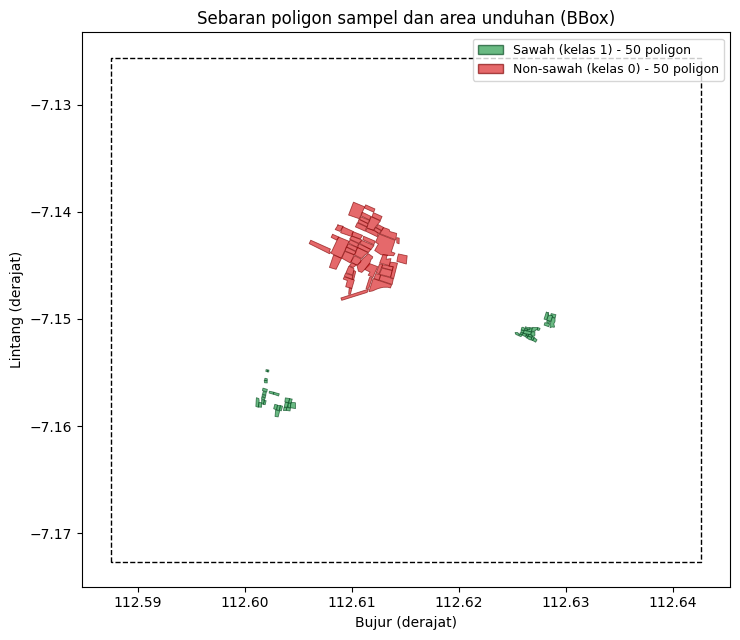

In [5]:
from shapely.geometry import shape
from shapely.geometry import box as shp_box

fig, ax = plt.subplots(figsize=(9, 6.5))
gpd.GeoSeries([shape(g) for g in geoms_non]).plot(
    ax=ax, facecolor="#d7191c", edgecolor="#7f0000", alpha=0.65, linewidth=0.6)
gpd.GeoSeries([shape(g) for g in geoms_sawah]).plot(
    ax=ax, facecolor="#1a9641", edgecolor="#00441b", alpha=0.65, linewidth=0.6)
gpd.GeoSeries([shp_box(*BBOX)]).boundary.plot(ax=ax, color="k", linestyle="--", linewidth=1)

ax.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, fc="#1a9641", ec="#00441b", alpha=0.65,
                  label=f"Sawah (kelas 1) - {len(geoms_sawah)} poligon"),
    plt.Rectangle((0, 0), 1, 1, fc="#d7191c", ec="#7f0000", alpha=0.65,
                  label=f"Non-sawah (kelas 0) - {len(geoms_non)} poligon"),
], loc="upper right", fontsize=9)
ax.set_title("Sebaran poligon sampel dan area unduhan (BBox)")
ax.set_xlabel("Bujur (derajat)")
ax.set_ylabel("Lintang (derajat)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 3. Mengunduh Sentinel-2A (GeoTIFF) dari Copernicus

Pengunduhan memakai **Sentinel Hub API** di Copernicus Data Space dalam tiga tahap:

1. **`get_token`**: meminta token akses OAuth dengan Client ID dan Secret.
2. **`search_scenes`**: mencari scene Sentinel-2 L2A di atas `BBOX` pada rentang tanggal tertentu. Scene difilter berdasarkan satelit (`S2A`) dan tutupan awan, lalu diurutkan dari yang paling bersih.
3. **`download_scene`**: mengunduh area `BBOX` dari scene terpilih lewat *Process API* dengan ketentuan:
   - proyeksi **UTM** (zona dihitung otomatis dengan `utm_epsg`), resolusi **10 m**
   - **6 band reflektansi**: B02 (biru), B03 (hijau), B04 (merah), B08 (NIR), B11 (SWIR-1), B12 (SWIR-2)
   - piksel **awan, bayangan awan, cirrus, dan salju dibuang** memakai band **SCL** (*Scene Classification Layer*) lewat *evalscript*. Kelas SCL yang dibuang: 0, 1, 3, 8, 9, 10, 11.

Fungsi `fetch_sentinel2a` mencoba hingga `MAX_TRIES` scene terbaik, lalu memakai scene yang fraksi piksel validnya mencapai `MIN_VALID` (atau yang terbaik bila tidak ada yang mencapai). Hasilnya disimpan sebagai `sentinel2a_aoi.tif` beserta catatan metadata `sentinel2a_aoi_info.txt`.

Bila `sentinel2a_aoi.tif` sudah ada, langkah unduh **dilewati otomatis**. Kamu juga bisa menaruh GeoTIFF dari Copernicus Browser secara manual, asalkan urutan bandnya sama.

In [6]:
# Kredensial hanya diminta jika citra belum pernah diunduh.
# Isi lewat environment variable CDSE_CLIENT_ID / CDSE_CLIENT_SECRET, atau ketik saat diminta.
if TIF_IN.exists():
    CLIENT_ID = CLIENT_SECRET = None
else:
    CLIENT_ID = os.environ.get("CDSE_CLIENT_ID") or input("CDSE Client ID: ").strip()
    CLIENT_SECRET = os.environ.get("CDSE_CLIENT_SECRET") or getpass.getpass("CDSE Client Secret: ").strip()

In [7]:
def get_token():
    r = requests.post(TOKEN_URL, data={
        "grant_type": "client_credentials",
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET,
    }, timeout=60)
    if r.status_code != 200:
        raise RuntimeError(f"Gagal mengambil token ({r.status_code}): {r.text[:300]}\n"
                           "Cek CLIENT_ID dan CLIENT_SECRET (dashboard Sentinel Hub).")
    return r.json()["access_token"]


def search_scenes(token):
    body = {
        "collections": ["sentinel-2-l2a"],
        "datetime": f"{START_DATE}T00:00:00Z/{END_DATE}T23:59:59Z",
        "bbox": list(BBOX),
        "limit": 100,
    }
    headers = {"Authorization": f"Bearer {token}"}
    feats = []
    while True:
        r = requests.post(CATALOG_URL, json=body, headers=headers, timeout=120)
        if r.status_code != 200:
            raise RuntimeError(f"Pencarian katalog gagal ({r.status_code}): {r.text[:300]}")
        js = r.json()
        feats += js.get("features", [])
        nxt = js.get("context", {}).get("next")
        if not nxt:
            break
        body["next"] = nxt

    cand = []
    for it in feats:
        p = it.get("properties", {})
        cc = p.get("eo:cloud_cover")
        if cc is None or cc > MAX_CLOUD:
            continue
        if PLATFORM_PREFIX and not it["id"].upper().startswith(PLATFORM_PREFIX):
            continue
        cand.append((cc, p["datetime"], it["id"]))
    cand.sort()   # urut dari awan paling sedikit
    log(f"Scene ditemukan: {len(feats)} | lolos filter ({PLATFORM_PREFIX or 'semua'}, "
        f"awan <= {MAX_CLOUD}%): {len(cand)}")
    return cand


def utm_epsg(lon, lat):
    # Kode EPSG zona UTM (326xx = utara, 327xx = selatan)
    return (32700 if lat < 0 else 32600) + int((lon + 180) // 6) + 1


def build_evalscript():
    # Evalscript dijalankan di server Copernicus: mengembalikan 6 band,
    # dan 0 untuk piksel tanpa data / awan / bayangan / cirrus / salju (kelas SCL).
    mask = " || [0,1,3,8,9,10,11].indexOf(s.SCL) >= 0" if MASK_CLOUD else ""
    return ('//VERSION=3\n'
            'function setup() {\n'
            '  return {\n'
            '    input: [{bands: ["B02","B03","B04","B08","B11","B12","SCL","dataMask"]}],\n'
            '    output: {bands: 6, sampleType: "FLOAT32"}\n'
            '  };\n'
            '}\n'
            'function evaluatePixel(s) {\n'
            f'  var bad = (s.dataMask == 0){mask};\n'
            '  if (bad) return [0,0,0,0,0,0];\n'
            '  return [s.B02, s.B03, s.B04, s.B08, s.B11, s.B12];\n'
            '}\n')

In [8]:
def download_scene(token, when):
    """Unduh area sampel dari satu scene: UTM, 10 m, 6 band reflektansi (float32)."""
    epsg = utm_epsg((BBOX[0] + BBOX[2]) / 2, (BBOX[1] + BBOX[3]) / 2)
    minx, miny, maxx, maxy = transform_bounds("EPSG:4326", f"EPSG:{epsg}", *BBOX)
    # Bulatkan ke kelipatan 10 m agar selaras dengan grid piksel Sentinel-2
    minx, miny = math.floor(minx / 10) * 10, math.floor(miny / 10) * 10
    maxx, maxy = math.ceil(maxx / 10) * 10, math.ceil(maxy / 10) * 10
    w, h = (maxx - minx) // 10, (maxy - miny) // 10
    if w > 2500 or h > 2500:
        raise RuntimeError(f"Area terlalu besar ({w}x{h} piksel, maks 2500). "
                           "Kecilkan BUFFER_M.")

    t = dt.datetime.fromisoformat(when.replace("Z", "+00:00")).astimezone(dt.timezone.utc)
    fmt = "%Y-%m-%dT%H:%M:%SZ"
    body = {
        "input": {
            "bounds": {
                "bbox": [minx, miny, maxx, maxy],
                "properties": {"crs": f"http://www.opengis.net/def/crs/EPSG/0/{epsg}"},
            },
            "data": [{
                "type": "sentinel-2-l2a",
                "dataFilter": {
                    "timeRange": {"from": (t - dt.timedelta(minutes=1)).strftime(fmt),
                                  "to": (t + dt.timedelta(minutes=1)).strftime(fmt)},
                    "mosaickingOrder": "leastCC",
                },
            }],
        },
        "output": {
            "resx": 10, "resy": 10,
            "responses": [{"identifier": "default", "format": {"type": "image/tiff"}}],
        },
        "evalscript": build_evalscript(),
    }
    r = requests.post(PROCESS_URL, json=body, timeout=300, headers={
        "Authorization": f"Bearer {token}", "Accept": "image/tiff"})
    if r.status_code != 200:
        raise RuntimeError(f"Unduhan gagal ({r.status_code}): {r.text[:400]}")
    return r.content, epsg


def valid_fraction(tif_bytes):
    # Fraksi piksel yang berisi data (bukan 0 / NaN) di area unduhan
    from rasterio.io import MemoryFile
    with MemoryFile(tif_bytes) as mf, mf.open() as src:
        arr = src.read()
    return float((np.any(arr != 0, axis=0) & np.isfinite(arr).all(axis=0)).mean())


def fetch_sentinel2a():
    token = get_token()
    cand = search_scenes(token)
    if not cand:
        raise RuntimeError(
            f"Tidak ada scene {PLATFORM_PREFIX or ''} dengan awan <= {MAX_CLOUD}% pada "
            f"{START_DATE} s/d {END_DATE}. Perlebar START_DATE/END_DATE atau naikkan "
            "MAX_CLOUD (atau PLATFORM_PREFIX=None untuk semua satelit).")

    best = None
    for cc, when, sid in cand[:MAX_TRIES]:
        data, epsg = download_scene(token, when)
        frac = valid_fraction(data)
        log(f"  {sid[:40]}... | {when} | awan tile {cc:.1f}% | piksel valid {frac:.1%}")
        if best is None or frac > best["frac"]:
            best = dict(frac=frac, data=data, when=when, sid=sid, cc=cc, epsg=epsg)
        if frac >= MIN_VALID:
            break

    TIF_IN.write_bytes(best["data"])
    INFO_TXT.write_text(
        f"Scene    : {best['sid']}\nAkuisisi : {best['when']}\n"
        f"Awan tile: {best['cc']:.1f}%\nPiksel valid di AOI: {best['frac']:.1%}\n"
        f"CRS      : EPSG:{best['epsg']}\nResolusi : 10 m\n"
        f"Band     : {', '.join(BAND_NAMES)} (reflektansi 0-1)\n"
        f"Masking awan (SCL): {MASK_CLOUD}\n", encoding="utf-8")
    log(f"Scene dipakai: {best['sid']} ({best['when']}), valid {best['frac']:.1%}")
    log("Tersimpan:", TIF_IN, "dan", INFO_TXT)


if TIF_IN.exists():
    log(f"{TIF_IN.name} sudah ada -> langkah unduh dilewati.")
else:
    fetch_sentinel2a()

sentinel2a_aoi.tif sudah ada -> langkah unduh dilewati.


### Informasi citra yang dipakai

Setelah unduhan selesai, ringkasan scene tersimpan di `sentinel2a_aoi_info.txt`. Sel berikut menampilkan isinya.

In [9]:
print(INFO_TXT.read_text(encoding="utf-8"))

Scene    : S2A_MSIL2A_20260713T024141_N0512_R089_T49MFN_20260713T071619.SAFE
Akuisisi : 2026-07-13T03:00:01.845Z
Awan tile: 4.0%
Piksel valid di AOI: 97.9%
CRS      : EPSG:32749
Resolusi : 10 m
Band     : B02, B03, B04, B08, B11, B12 (reflektansi 0-1)
Masking awan (SCL): True



| Informasi | Nilai | Keterangan |
|---|---|---|
| Scene | `S2A_MSIL2A_20260713T024141_N0512_R089_T49MFN_20260713T071619.SAFE` | `S2A` = Sentinel-2A, `MSIL2A` = Level-2A (reflektansi permukaan, sudah terkoreksi atmosfer), `N0512` = versi pemrosesan, `R089` = orbit relatif, `T49MFN` = kode tile |
| Waktu akuisisi | 13 Juli 2026, 03:00 UTC (sekitar 10:00 WIB) | Masuk dalam rentang pencarian `START_DATE` sampai `END_DATE` |
| Tutupan awan (level tile) | 4,0% | Jauh di bawah batas `MAX_CLOUD` = 30% |
| Piksel valid di area sampel | 97,9% | Di atas batas `MIN_VALID` = 90%. Sisanya (2,1%) adalah piksel `NaN` hasil masking awan dan bayangan awan |
| Sistem koordinat | EPSG:32749 (UTM zona 49S) | Satuan meter, sehingga luas bisa dihitung langsung |
| Resolusi | 10 m | 1 piksel = 100 m² |
| Band | B02, B03, B04, B08, B11, B12 | Reflektansi 0 sampai 1 |
| Masking awan (SCL) | Ya | Kelas awan, bayangan awan, cirrus, dan salju dibuang |

**Mengapa tanggal akuisisi penting.** Peta ini menggambarkan kondisi lahan pada **13 Juli 2026**. Pada bulan Juli umumnya musim kemarau di Jawa Timur, sehingga sawah bisa berada pada berbagai fase (masih digenangi, vegetatif, sudah panen, atau bera). Fase tersebut mengubah nilai NDVI, NDWI, dan band SWIR, sehingga hasil klasifikasi pada tanggal lain dapat berbeda.

## 4. Membaca citra GeoTIFF

Citra dibaca dengan `rasterio` menjadi array `stack` berukuran `(6 band, tinggi, lebar)`. Piksel yang seluruh bandnya bernilai 0 (hasil masking awan di server) atau tidak valid diubah menjadi **NaN** supaya tidak ikut dilatih maupun diklasifikasikan.

Dictionary `B` memetakan nama band ke arraynya (`B["B04"]` = band merah, dan seterusnya) agar rumus indeks mudah dibaca.

In [10]:
with rasterio.open(TIF_IN) as src:
    stack = src.read().astype("float32")
    crs, transform = src.crs, src.transform
if stack.shape[0] != len(BAND_NAMES):
    raise RuntimeError(f"TIF punya {stack.shape[0]} band, harus {len(BAND_NAMES)} "
                       f"({', '.join(BAND_NAMES)}).")
invalid = np.all(stack == 0, axis=0) | ~np.isfinite(stack).all(axis=0)
stack[:, invalid] = np.nan
H, W = stack.shape[1:]
log(f"Ukuran citra: {W} x {H} piksel | CRS: {crs} | piksel tanpa data: {invalid.mean():.1%}")
B = dict(zip(BAND_NAMES, stack))

Ukuran citra: 611 x 524 piksel | CRS: EPSG:32749 | piksel tanpa data: 2.1%


## 5. Fitur: band spektral + indeks

Selain 6 band asli, ditambahkan **4 indeks spektral** yang membantu memisahkan sawah dari non-sawah. Total ada **10 fitur** per piksel.

| Fitur | Rumus | Kegunaan |
|---|---|---|
| **NDVI** | `(B08 - B04) / (B08 + B04)` | Kehijauan/kerapatan vegetasi. Padi yang sedang tumbuh bernilai tinggi. |
| **NDWI** | `(B03 - B08) / (B03 + B08)` | Kandungan air permukaan. Sawah yang digenangi memberi nilai lebih tinggi. |
| **NDBI** | `(B11 - B08) / (B11 + B08)` | Area terbangun. Permukiman dan bangunan bernilai tinggi. |
| **EVI** | `2.5 * (B08 - B04) / (B08 + 6*B04 - 7.5*B02 + 1)` | Vegetasi yang lebih tahan terhadap efek atmosfer dan saturasi dibanding NDVI. |

Suku `1e-10` pada fungsi `nd()` mencegah pembagian dengan nol.

In [11]:
def nd(a, b):
    # Normalized difference: (a - b) / (a + b)
    return (a - b) / (a + b + 1e-10)

ndvi = nd(B["B08"], B["B04"])
ndwi = nd(B["B03"], B["B08"])
ndbi = nd(B["B11"], B["B08"])
evi = 2.5 * (B["B08"] - B["B04"]) / (B["B08"] + 6 * B["B04"] - 7.5 * B["B02"] + 1)

feats = np.concatenate([stack, np.stack([ndvi, ndwi, ndbi, evi])]).astype("float32")
FEATURE_NAMES = BAND_NAMES + ["NDVI", "NDWI", "NDBI", "EVI"]
F = feats.shape[0]

## 6. Rasterisasi poligon sampel

Poligon sampel (koordinat lon/lat) diubah ke sistem koordinat citra (`transform_geom`), lalu **dirasterisasi** menjadi grid yang sama dengan citra. Setiap piksel di dalam poligon diberi **ID poligon**, sedangkan piksel di luar poligon bernilai 0.

Hanya piksel yang berada di dalam poligon **dan** memiliki data valid (bebas awan) yang dipakai sebagai data berlabel (`labeled`). Notebook juga melaporkan jumlah poligon dan piksel yang terpakai per kelas, serta memberi peringatan bila ada poligon yang seluruhnya tertutup awan atau berada di luar citra.

In [12]:
poly_label, shapes, pid = {}, [], 0
for geoms, kelas in ((geoms_non, 0), (geoms_sawah, 1)):
    for g in geoms:
        pid += 1
        poly_label[pid] = kelas
        shapes.append((transform_geom("EPSG:4326", crs, g), pid))

poly_raster = features.rasterize(shapes, out_shape=(H, W), transform=transform,
                                 fill=0, dtype="int32")
labeled = (poly_raster > 0) & np.isfinite(feats).all(axis=0)
present = np.unique(poly_raster[labeled])

for k, nama in ((0, "non-sawah"), (1, "sawah")):
    ids = [p for p in present if poly_label[p] == k]
    npx = int(np.isin(poly_raster, ids).sum())
    log(f"Kelas {k} ({nama}): {len(ids)} poligon terpakai, {npx} piksel bebas awan")
if len(present) < len(poly_label):
    log(f"PERINGATAN: {len(poly_label) - len(present)} poligon tidak punya piksel valid "
        "(tertutup awan atau di luar citra).")

Kelas 0 (non-sawah): 50 poligon terpakai, 3399 piksel bebas awan
Kelas 1 (sawah): 50 poligon terpakai, 604 piksel bebas awan


### Jumlah piksel per kelas

Hasil rasterisasi di atas, diringkas dalam tabel (hanya piksel bebas awan yang dihitung):

| Kelas | Poligon terpakai | Jumlah piksel | Porsi |
|---|---|---|---|
| Non-sawah (kelas 0) | 50 | **3.399** | 84,9% |
| Sawah (kelas 1) | 50 | **604** | 15,1% |
| **Total** | 100 | **4.003** | 100% |

Setiap piksel mewakili area 10 m x 10 m (100 m²). Piksel-piksel inilah yang menjadi data berlabel untuk melatih dan menguji model.

## 7. Pembagian data training dan testing per poligon

Pembagian dilakukan **per poligon, bukan per piksel**. Piksel yang bertetangga di dalam satu poligon sangat mirip. Jika dipisah per piksel, sebagian piksel poligon yang sama akan masuk training dan sebagian lagi testing, sehingga akurasi tampak terlalu tinggi (*spatial data leakage*).

Dengan pembagian per poligon, **70% poligon** tiap kelas menjadi data latih dan **30%** sisanya menjadi data uji yang benar-benar belum pernah dilihat model.

**Yang dipelajari model adalah piksel, bukan poligon.** Setiap piksel di dalam poligon mewarisi label poligonnya (sawah atau non-sawah) dan menjadi satu baris data berisi 10 fitur dan 1 label. Poligon hanya dipakai sebagai dasar pembagian training dan testing.

In [13]:
rng = np.random.default_rng(SEED)
train_ids = []
for k in (0, 1):
    ids = [p for p in present if poly_label[p] == k]
    rng.shuffle(ids)
    train_ids += ids[:max(1, int(round(len(ids) * TRAIN_FRAC)))]

m_train = labeled & np.isin(poly_raster, train_ids)
m_test = labeled & ~m_train
lab_map = np.zeros(poly_raster.max() + 1, dtype="uint8")
for p, k in poly_label.items():
    lab_map[p] = k

X_train, y_train = feats[:, m_train].T, lab_map[poly_raster[m_train]]
X_test, y_test = feats[:, m_test].T, lab_map[poly_raster[m_test]]
log(f"Poligon training: {len(train_ids)} | testing: {len(present) - len(train_ids)}")
log(f"Piksel training: {len(y_train)} | testing: {len(y_test)}")

Poligon training: 70 | testing: 30
Piksel training: 3121 | testing: 882


### Jumlah data training dan testing per kelas

Sel berikut menghitung jumlah piksel training dan testing untuk masing-masing kelas.

In [14]:
for k, nama in ((0, "non-sawah"), (1, "sawah")):
    n_tr = int((y_train == k).sum())
    n_te = int((y_test == k).sum())
    log(f"{nama:<10}: training {n_tr} piksel | testing {n_te} piksel | total {n_tr + n_te} piksel")

non-sawah : training 2738 piksel | testing 661 piksel | total 3399 piksel
sawah     : training 383 piksel | testing 221 piksel | total 604 piksel


| Kelas | Poligon training | Poligon testing | Piksel training | Piksel testing | Total piksel |
|---|---|---|---|---|---|
| Non-sawah | 35 | 15 | 2.738 | 661 | 3.399 |
| Sawah | 35 | 15 | 383 | 221 | 604 |
| **Total** | **70** | **30** | **3.121** | **882** | **4.003** |

Pembagian dilakukan per poligon (35 dari 50 poligon tiap kelas untuk training, 15 untuk testing), sedangkan yang masuk ke model adalah piksel di dalam poligon-poligon tersebut. Karena ukuran poligon berbeda-beda, proporsi piksel training dan testing tidak persis 70:30: untuk sawah 63,4% : 36,6%, untuk non-sawah 80,6% : 19,4%.

### Jumlah poligon dan piksel per kelas

| Kelas | Poligon training | Poligon testing | Piksel training | Piksel testing | Total piksel |
|---|---|---|---|---|---|
| **Non-sawah** | 35 | 15 | 2.738 | 661 | **3.399** |
| **Sawah** | 35 | 15 | 383 | 221 | **604** |
| **Total** | 70 | 30 | 3.121 | 882 | 4.003 |

- Data yang masuk ke Random Forest berbentuk tabel `X_train` berukuran `(3121, 10)` dengan label `y_train` sebanyak 3.121 baris. Satu baris adalah satu piksel.
- Jumlah poligon kedua kelas sama (50 per kelas), tetapi jumlah pikselnya berbeda jauh karena poligon sawah lebih kecil. Dampaknya dibahas pada bagian *Ketidakseimbangan kelas* di bawah.
- Hanya piksel bebas awan yang dihitung. Piksel di dalam poligon yang tertutup awan sudah dibuang oleh masking SCL.

## 8. Melatih dan mengevaluasi model

**Random Forest** adalah kumpulan banyak pohon keputusan (di sini `N_TREES = 200`) yang masing-masing dilatih pada sampel data berbeda, lalu hasilnya digabung lewat *voting*. Metode ini tahan terhadap *overfitting*, tidak memerlukan normalisasi fitur, dan memberi ukuran **kepentingan fitur**.

Evaluasi memakai data uji (poligon yang tidak dipakai saat training):

- **Confusion matrix**: baris = kelas aktual, kolom = kelas prediksi (urutan 0 = non-sawah, 1 = sawah).
- **Overall Accuracy**: proporsi piksel uji yang diprediksi benar.
- **Kappa**: kesepakatan prediksi dan aktual setelah mengoreksi kebetulan. Nilai mendekati 1 berarti sangat baik.
- **Precision / Recall / F1** per kelas, dan **kepentingan fitur** untuk melihat band atau indeks yang paling berperan.

In [15]:
rf = RandomForestClassifier(n_estimators=N_TREES, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
pred_test = rf.predict(X_test)

log("\nConfusion matrix (baris=aktual, kolom=prediksi; urutan 0=non-sawah, 1=sawah):")
log(confusion_matrix(y_test, pred_test, labels=[0, 1]))
log(f"Overall Accuracy : {accuracy_score(y_test, pred_test):.4f}")
log(f"Kappa            : {cohen_kappa_score(y_test, pred_test):.4f}")
log(classification_report(y_test, pred_test, labels=[0, 1],
                          target_names=["non-sawah", "sawah"], digits=3))
log("Kepentingan fitur:")
for n, v in sorted(zip(FEATURE_NAMES, rf.feature_importances_), key=lambda x: -x[1]):
    log(f"  {n:5s} {v:.3f}")


Confusion matrix (baris=aktual, kolom=prediksi; urutan 0=non-sawah, 1=sawah):
[[660   1]
 [ 11 210]]
Overall Accuracy : 0.9864
Kappa            : 0.9632
              precision    recall  f1-score   support

   non-sawah      0.984     0.998     0.991       661
       sawah      0.995     0.950     0.972       221

    accuracy                          0.986       882
   macro avg      0.989     0.974     0.982       882
weighted avg      0.987     0.986     0.986       882

Kepentingan fitur:
  B12   0.264
  B02   0.188
  NDWI  0.160
  NDVI  0.094
  B11   0.073
  EVI   0.072
  NDBI  0.051
  B04   0.038
  B08   0.034
  B03   0.027


### Membaca hasil evaluasi

Data uji berisi **882 piksel** dari 30 poligon yang tidak dipakai saat training (661 piksel non-sawah dan 221 piksel sawah).

**Confusion matrix**

| | Prediksi non-sawah | Prediksi sawah |
|---|---|---|
| **Aktual non-sawah** | 660 | 1 |
| **Aktual sawah** | 11 | 210 |

**Metrik per kelas**

| Kelas | Precision | Recall | F1-score | Jumlah piksel uji |
|---|---|---|---|---|
| Non-sawah | 0,984 | 0,998 | 0,991 | 661 |
| Sawah | 0,995 | 0,950 | 0,972 | 221 |

- **Overall Accuracy 0,9864**: dari 882 piksel uji, 870 diprediksi benar (660 + 210).
- **Kappa 0,9632**: kesepakatan antara prediksi dan data aktual sangat tinggi setelah dikoreksi kebetulan.
- **Precision sawah 0,995**: dari 211 piksel yang diprediksi sawah, 210 benar. Hanya 1 piksel non-sawah yang salah dianggap sawah.
- **Recall sawah 0,950**: dari 221 piksel sawah sebenarnya, 210 berhasil dikenali dan 11 terlewat (diprediksi non-sawah).

Heatmap berikut menampilkan confusion matrix yang sama. Angka di setiap kotak adalah jumlah piksel, dan persentase di dalam kurung dihitung per baris (per kelas aktual).

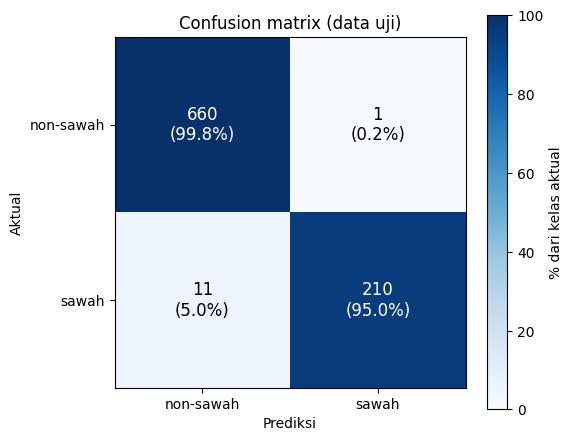

In [16]:
cm = confusion_matrix(y_test, pred_test, labels=[0, 1])
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
kelas = ["non-sawah", "sawah"]

fig, ax = plt.subplots(figsize=(5.8, 4.8))
im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
for i in range(2):
    for j in range(2):
        warna = "white" if cm_pct[i, j] > 50 else "black"
        ax.text(j, i, f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)",
                ha="center", va="center", color=warna, fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(kelas)
ax.set_yticks([0, 1])
ax.set_yticklabels(kelas)
ax.set_xlabel("Prediksi")
ax.set_ylabel("Aktual")
ax.set_title("Confusion matrix (data uji)")
fig.colorbar(im, ax=ax, label="% dari kelas aktual")
plt.tight_layout()
plt.show()

### Ketidakseimbangan kelas

Jumlah piksel kedua kelas **tidak seimbang**: sawah hanya **604 piksel (15,1%)** dari seluruh piksel sampel, sedangkan non-sawah **3.399 piksel (84,9%)**. Penyebabnya, poligon sawah yang digambar lebih kecil: rata-rata sekitar 12 piksel per poligon, dibanding sekitar 68 piksel per poligon untuk non-sawah.

Akibatnya, akurasi keseluruhan saja kurang cukup untuk menilai model. Pada data uji, model yang selalu menebak "non-sawah" sudah mencapai akurasi 74,9% (661 dari 882 piksel). Karena itu perhatikan juga metrik kelas sawah:

- Recall sawah (0,950) lebih rendah dari recall non-sawah (0,998). Kelas yang lebih sedikit memang lebih sering terlewat: 5,0% piksel sawah uji (11 dari 221) salah diprediksi non-sawah, sedangkan hanya 0,15% piksel non-sawah uji (1 dari 661) salah diprediksi sawah.
- F1 sawah (0,972) tetap tinggi, jadi ketidakseimbangan ini belum merusak kinerja secara serius pada data uji.

Bila ingin meningkatkan recall sawah, dua cara yang umum adalah menambah poligon sawah, atau memakai `class_weight="balanced"` pada `RandomForestClassifier` agar kelas minoritas diberi bobot lebih besar.

kelas       training  testing   total  porsi total
non-sawah       2738      661    3399        84.9%
sawah            383      221     604        15.1%


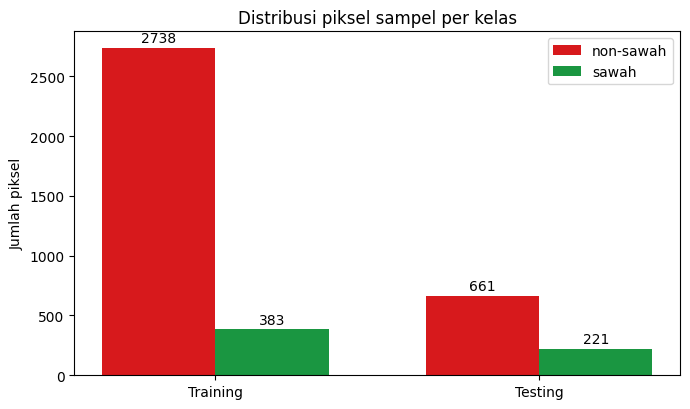

In [17]:
n_train = np.bincount(y_train, minlength=2)
n_test = np.bincount(y_test, minlength=2)
n_total = n_train + n_test
nama_kelas = ["non-sawah", "sawah"]

print(f"{'kelas':<10} {'training':>9} {'testing':>8} {'total':>7} {'porsi total':>12}")
for k in (0, 1):
    print(f"{nama_kelas[k]:<10} {n_train[k]:>9} {n_test[k]:>8} {n_total[k]:>7} {n_total[k] / n_total.sum():>12.1%}")

x = np.arange(2)
lebar = 0.35
fig, ax = plt.subplots(figsize=(7, 4.2))
b0 = ax.bar(x - lebar / 2, [n_train[0], n_test[0]], lebar, color="#d7191c", label="non-sawah")
b1 = ax.bar(x + lebar / 2, [n_train[1], n_test[1]], lebar, color="#1a9641", label="sawah")
ax.bar_label(b0, padding=2)
ax.bar_label(b1, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(["Training", "Testing"])
ax.set_ylabel("Jumlah piksel")
ax.set_title("Distribusi piksel sampel per kelas")
ax.legend()
plt.tight_layout()
plt.show()

### Perbandingan: tanpa vs dengan `class_weight="balanced"`

Untuk menguji apakah ketidakseimbangan kelas berpengaruh, dua Random Forest dilatih pada **data training yang sama** dan diuji pada **data uji yang sama** (data uji tidak diubah sama sekali):

- **Baseline**: tanpa pembobotan (model `rf` di atas).
- **Balanced**: `class_weight="balanced"`, kelas sawah diberi bobot lebih besar sesuai kelangkaannya di data training.

Karena Random Forest bersifat acak dan data uji hanya 30 poligon, perbandingan diulang dengan 5 nilai `random_state` berbeda dan ditampilkan sebagai rata-rata ± simpangan baku. Selisih yang lebih kecil dari simpangan baku tidak perlu dianggap sebagai perbaikan nyata.

Cara membaca hasilnya:

- Fokus pada **recall sawah**, **F1 sawah**, dan **Kappa**, bukan hanya Overall Accuracy.
- Bila `balanced` menaikkan recall sawah tetapi menurunkan precision sawah, artinya lebih banyak sawah yang terdeteksi dengan harga lebih banyak salah tebak. Pertimbangkan mana yang lebih penting untuk tujuan Anda.
- Bila selisihnya kecil, model baseline sudah memadai dan ketidakseimbangan ini tidak perlu ditangani lebih jauh.
- Bila `balanced` lebih baik, tambahkan `class_weight="balanced"` pada `rf` (bagian 8) **dan** `rf_final` (bagian 9) agar peta akhir memakai pengaturan yang sama.


Perbandingan class_weight (rata-rata +/- simpangan baku dari 5 seed)
Metrik                          Baseline              Balanced
OA                        0.9857 +/- 0.0009        0.9832 +/- 0.0005
Kappa                     0.9613 +/- 0.0025        0.9543 +/- 0.0012
Prec sawah                0.9962 +/- 0.0019        0.9990 +/- 0.0019
Recall sawah              0.9466 +/- 0.0034        0.9339 +/- 0.0022
F1 sawah                  0.9708 +/- 0.0019        0.9654 +/- 0.0010
Recall non-sawah          0.9988 +/- 0.0006        0.9997 +/- 0.0006

Confusion matrix Baseline (seed=42; baris=aktual, kolom=prediksi; 0=non-sawah, 1=sawah):
[[660   1]
 [ 11 210]]

Confusion matrix Balanced (seed=42; baris=aktual, kolom=prediksi; 0=non-sawah, 1=sawah):
[[661   0]
 [ 15 206]]


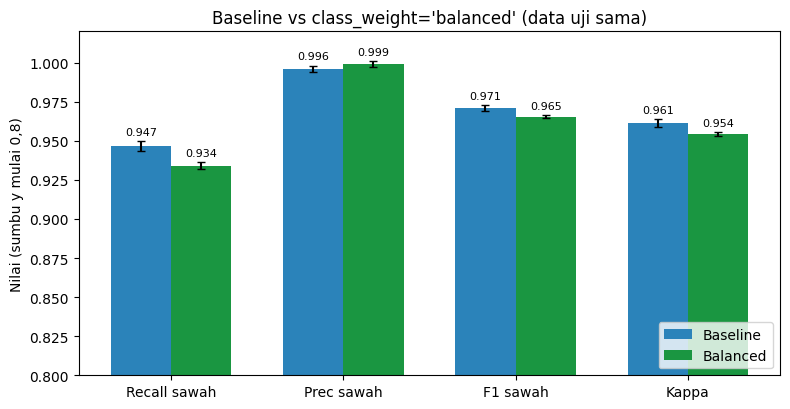

In [18]:
from sklearn.metrics import precision_recall_fscore_support

SEEDS = [42, 1, 2, 3, 4]
KONFIG = {
    "Baseline": None,
    "Balanced": "balanced",
}
METRIK = ["OA", "Kappa", "Prec sawah", "Recall sawah", "F1 sawah", "Recall non-sawah"]

hasil = {nama: {m: [] for m in METRIK} for nama in KONFIG}
cm_seed_utama = {}

for nama, cw in KONFIG.items():
    for s in SEEDS:
        model = RandomForestClassifier(n_estimators=N_TREES, class_weight=cw,
                                       random_state=s, n_jobs=-1)
        model.fit(X_train, y_train)          # hanya data training
        p = model.predict(X_test)            # data uji apa adanya
        pr, rc, f1, _ = precision_recall_fscore_support(
            y_test, p, labels=[0, 1], zero_division=0)
        hasil[nama]["OA"].append(accuracy_score(y_test, p))
        hasil[nama]["Kappa"].append(cohen_kappa_score(y_test, p))
        hasil[nama]["Prec sawah"].append(pr[1])
        hasil[nama]["Recall sawah"].append(rc[1])
        hasil[nama]["F1 sawah"].append(f1[1])
        hasil[nama]["Recall non-sawah"].append(rc[0])
        if s == SEED:
            cm_seed_utama[nama] = confusion_matrix(y_test, p, labels=[0, 1])

log(f"\nPerbandingan class_weight (rata-rata +/- simpangan baku dari {len(SEEDS)} seed)")
log(f"{'Metrik':<18}" + "".join(f"{n:>22}" for n in KONFIG))
for m in METRIK:
    baris = f"{m:<18}"
    for nama in KONFIG:
        v = np.array(hasil[nama][m])
        baris += f"{v.mean():>14.4f} +/- {v.std():.4f}"
    log(baris)

for nama, cm_ in cm_seed_utama.items():
    log(f"\nConfusion matrix {nama} (seed={SEED}; baris=aktual, kolom=prediksi; 0=non-sawah, 1=sawah):")
    log(cm_)

# Diagram batang: metrik utama kedua konfigurasi
tampil = ["Recall sawah", "Prec sawah", "F1 sawah", "Kappa"]
x = np.arange(len(tampil))
lebar = 0.35
fig, ax = plt.subplots(figsize=(8, 4.2))
for i, (nama, warna) in enumerate(zip(KONFIG, ["#2b83ba", "#1a9641"])):
    rata = [np.mean(hasil[nama][m]) for m in tampil]
    sd = [np.std(hasil[nama][m]) for m in tampil]
    b = ax.bar(x + (i - 0.5) * lebar, rata, lebar, yerr=sd, capsize=3,
               color=warna, label=nama)
    ax.bar_label(b, fmt="%.3f", padding=3, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(tampil)
ax.set_ylim(0.8, 1.02)
ax.set_ylabel("Nilai (sumbu y mulai 0,8)")
ax.set_title("Baseline vs class_weight='balanced' (data uji sama)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Kepentingan fitur

Diagram berikut mengurutkan kontribusi tiap fitur terhadap keputusan Random Forest (*Gini importance*). Batang biru adalah band asli dan batang hijau adalah indeks spektral.

Tiga fitur teratas adalah **B12 (0,264)**, **B02 (0,188)**, dan **NDWI (0,160)**, yang bersama-sama menyumbang sekitar 61% dari total kepentingan. NDVI berada di urutan keempat (0,094).

Beberapa hal yang perlu diperhatikan saat menafsirkannya:

- B12 adalah band inframerah gelombang pendek (SWIR-2) yang peka terhadap kandungan air dan kelembapan, sedangkan NDWI mengukur air permukaan. Keduanya sejalan dengan ciri sawah yang lembap atau tergenang dibanding permukiman.
- NDVI yang biasanya jadi andalan untuk vegetasi justru bukan yang teratas. Kemungkinan penyebabnya, sampel non-sawah berupa permukiman, sehingga selisih kelembapan dan kecerahan sudah cukup memisahkan kedua kelas, tanpa harus bergantung pada kehijauan saja.
- Nilai *Gini importance* terbagi di antara fitur yang saling berkorelasi (band dan indeks yang dihitung dari band yang sama). Jadi angka ini menunjukkan seberapa sering fitur dipakai model, bukan hubungan sebab-akibat, dan sebaiknya tidak ditafsirkan secara berlebihan.

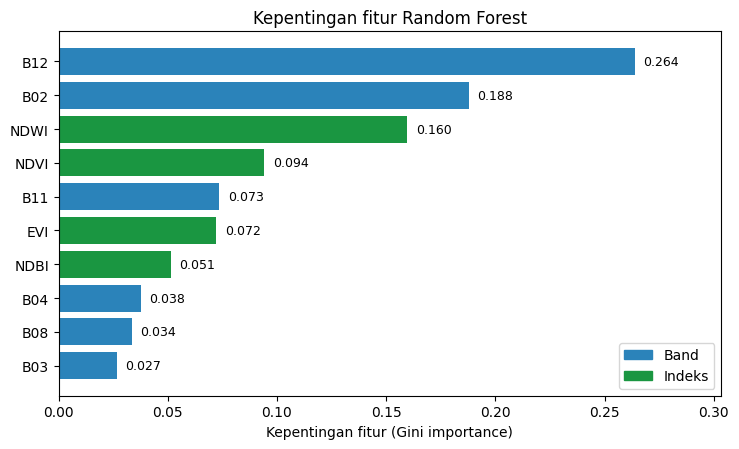

In [19]:
from matplotlib.patches import Patch

urut = np.argsort(rf.feature_importances_)
nama = np.array(FEATURE_NAMES)[urut]
nilai = rf.feature_importances_[urut]
indeks = {"NDVI", "NDWI", "NDBI", "EVI"}
warna = ["#1a9641" if n in indeks else "#2b83ba" for n in nama]

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.barh(nama, nilai, color=warna)
for y, v in enumerate(nilai):
    ax.text(v + 0.004, y, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, nilai.max() * 1.15)
ax.set_xlabel("Kepentingan fitur (Gini importance)")
ax.set_title("Kepentingan fitur Random Forest")
ax.legend(handles=[Patch(color="#2b83ba", label="Band"),
                   Patch(color="#1a9641", label="Indeks")], loc="lower right")
plt.tight_layout()
plt.show()

### Sebaran nilai fitur per kelas

Boxplot berikut membandingkan sebaran **NDVI**, **NDWI**, dan **B12** pada piksel sampel sawah dan non-sawah. Semakin kecil tumpang tindih antara kotak merah dan hijau, semakin mudah fitur tersebut memisahkan kedua kelas.

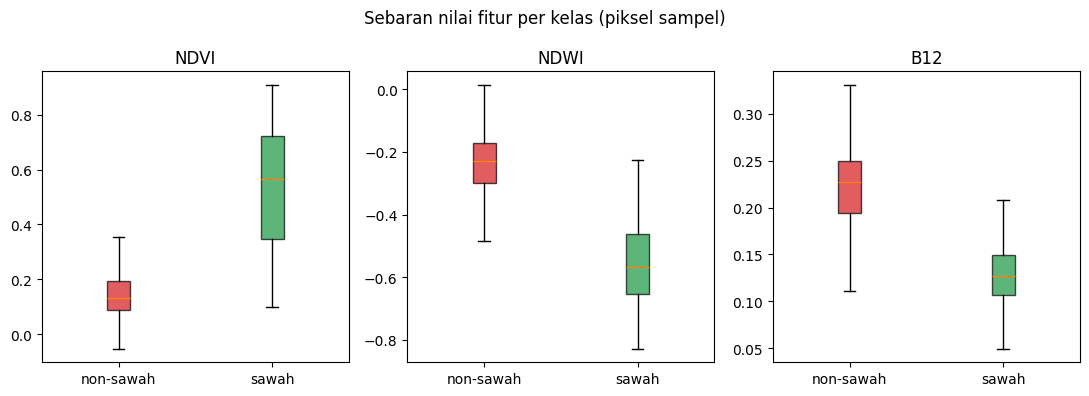

In [20]:
fitur_plot = ["NDVI", "NDWI", "B12"]
X_all = feats[:, labeled].T
y_all = lab_map[poly_raster[labeled]]

fig, axes = plt.subplots(1, len(fitur_plot), figsize=(11, 4))
for ax, nama in zip(axes, fitur_plot):
    j = FEATURE_NAMES.index(nama)
    data = [X_all[y_all == 0, j], X_all[y_all == 1, j]]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False)
    for kotak, warna in zip(bp["boxes"], ["#d7191c", "#1a9641"]):
        kotak.set_facecolor(warna)
        kotak.set_alpha(0.7)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["non-sawah", "sawah"])
    ax.set_title(nama)
fig.suptitle("Sebaran nilai fitur per kelas (piksel sampel)")
plt.tight_layout()
plt.show()

## 9. Klasifikasi seluruh citra

Setelah akurasi diukur dari data uji, **model akhir dilatih ulang dengan semua sampel** (training + testing) agar memanfaatkan seluruh informasi yang tersedia. Model akhir ini kemudian memprediksi **setiap piksel** pada citra.

Piksel tanpa data (tertutup awan, bayangan awan, dan sebagainya) diberi nilai `255` sebagai *nodata*, sehingga tidak diklasifikasikan. Karena citra berproyeksi UTM (satuan meter), luas tiap kelas dapat dihitung dari jumlah piksel dikalikan luas satu piksel (10 m x 10 m = 100 m²) dan dikonversi ke hektare.

In [21]:
# Model akhir dilatih ulang dengan SEMUA sampel; akurasi di atas tetap dari data uji.
rf_final = RandomForestClassifier(n_estimators=N_TREES, random_state=SEED, n_jobs=-1)
rf_final.fit(feats[:, labeled].T, lab_map[poly_raster[labeled]])

flat = feats.reshape(F, -1).T
ok = np.isfinite(flat).all(axis=1)
pred = np.full(flat.shape[0], 255, dtype="uint8")    # 255 = nodata
pred[ok] = rf_final.predict(flat[ok]).astype("uint8")
classified = pred.reshape(H, W)

if crs.is_projected:
    px_area = abs(transform.a * transform.e)
    log(f"\nLuas sawah    : {(classified == 1).sum() * px_area / 10000:.1f} ha")
    log(f"Luas non-sawah: {(classified == 0).sum() * px_area / 10000:.1f} ha")


Luas sawah    : 969.7 ha
Luas non-sawah: 2165.8 ha


## 10. Menyimpan GeoTIFF, peta, dan ringkasan

Tiga keluaran disimpan:

1. **`klasifikasi_sawah_s2a.tif`**: GeoTIFF 1 band (`uint8`, kompresi LZW) dengan nilai 1 = sawah, 0 = non-sawah, 255 = nodata. Peta warna (*colormap*) sudah ditanam, sehingga langsung berwarna di QGIS atau ArcGIS. Ini **hasil utama tugas**.
2. **`peta_klasifikasi.png`**: perbandingan citra RGB asli (kiri) dan hasil klasifikasi (kanan).
3. **`hasil_evaluasi.txt`**: seluruh catatan `log` (jumlah sampel, confusion matrix, akurasi, kappa, luas).

Citra RGB dibuat dari band B04 (merah), B03 (hijau), dan B02 (biru), lalu diregangkan kontrasnya dengan persentil 2-98% agar tampak jelas.

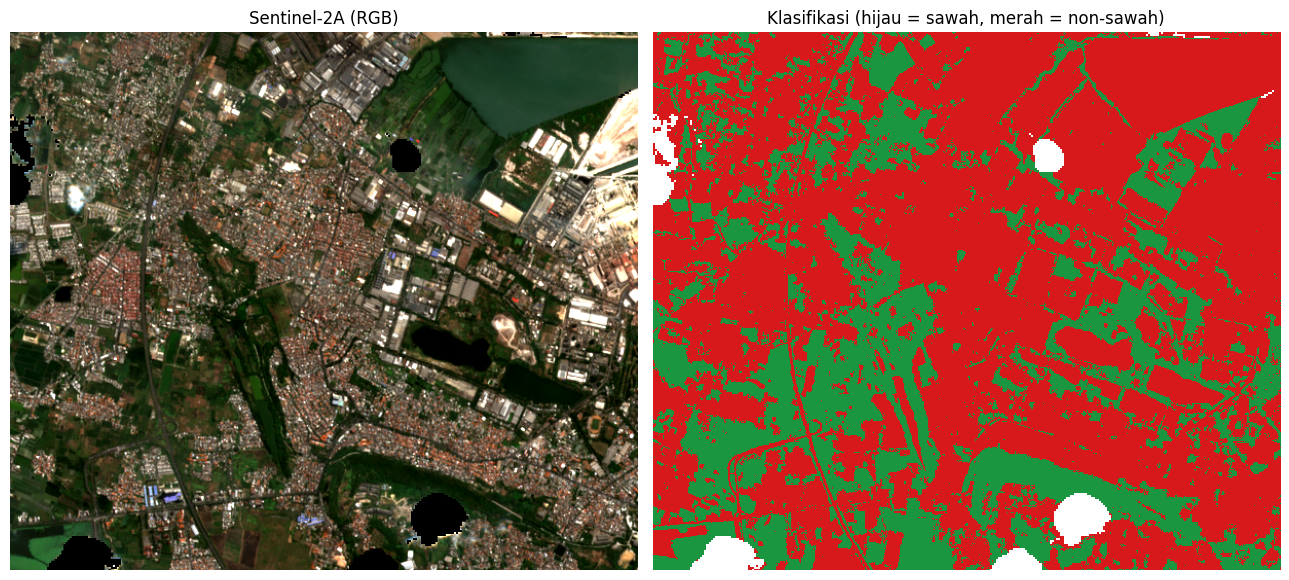


Selesai. Output:
  GeoTIFF  : c:\Users\OKAN\OneDrive\Dokumen\PSD\materi\klasifikasi_sawah\klasifikasi_sawah_s2a.tif
  Pratinjau: c:\Users\OKAN\OneDrive\Dokumen\PSD\materi\klasifikasi_sawah\peta_klasifikasi.png
  Evaluasi : c:\Users\OKAN\OneDrive\Dokumen\PSD\materi\klasifikasi_sawah\hasil_evaluasi.txt


In [22]:
with rasterio.open(OUT_TIF, "w", driver="GTiff", height=H, width=W, count=1,
                   dtype="uint8", crs=crs, transform=transform,
                   nodata=255, compress="lzw") as dst:
    dst.write(classified, 1)
    dst.set_band_description(1, "kelas (1=sawah, 0=non-sawah)")
    dst.write_colormap(1, {0: (215, 25, 28, 255), 1: (26, 150, 65, 255),
                           255: (0, 0, 0, 0)})

# Komposit RGB alami dengan peregangan kontras persentil 2-98%
rgb = np.dstack([B["B04"], B["B03"], B["B02"]])
lo, hi = np.nanpercentile(rgb, 2), np.nanpercentile(rgb, 98)
rgb = np.nan_to_num(np.clip((rgb - lo) / (hi - lo + 1e-10), 0, 1))

fig, ax = plt.subplots(1, 2, figsize=(13, 6))
ax[0].imshow(rgb)
ax[0].set_title("Sentinel-2A (RGB)")
ax[1].imshow(np.ma.masked_equal(classified, 255),
             cmap=ListedColormap(["#d7191c", "#1a9641"]), vmin=0, vmax=1,
             interpolation="nearest")
ax[1].set_title("Klasifikasi (hijau = sawah, merah = non-sawah)")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150)
plt.show()

OUT_TXT.write_text("\n".join(LOG), encoding="utf-8")
log("\nSelesai. Output:")
log("  GeoTIFF  :", OUT_TIF)
log("  Pratinjau:", OUT_PNG)
log("  Evaluasi :", OUT_TXT)

### Cara membaca peta hasil

- **Kiri**: citra Sentinel-2A dalam warna alami (RGB). Area **hitam** adalah piksel yang dibuang karena awan atau bayangan awan (hasil masking SCL).
- **Kanan**: hasil klasifikasi. **Hijau** = sawah (969,7 ha), **merah** = non-sawah (2.165,8 ha). Area **putih** adalah *nodata*, yaitu piksel yang sama dengan area hitam di citra kiri sehingga tidak diklasifikasikan.
- Kawasan permukiman dan industri yang padat terklasifikasi sebagai non-sawah (merah), sesuai dengan sampel non-sawah yang berupa permukiman.

### Catatan dan keterbatasan

- **Akurasi dihitung pada piksel di dalam poligon uji** (30 poligon, 882 piksel), bukan pada seluruh peta. Poligon latih dan uji berasal dari area yang sama dan mengelompok secara spasial (sawah pada dua kelompok kecil, non-sawah pada satu kelompok), sehingga angka 98,64% kemungkinan lebih optimis dibanding kondisi di seluruh area citra.
- **Seluruh sampel non-sawah berlabel permukiman** (kolom `label` pada `nonsawah.shp`). Model belum pernah melihat contoh non-sawah jenis lain: badan air atau tambak, vegetasi bukan padi (kebun, semak, hutan kecil), lahan terbuka, dan kawasan industri. Piksel seperti itu tetap dipaksa masuk ke salah satu dari dua kelas, sehingga berpotensi salah klasifikasi, terutama vegetasi lebat yang bisa terprediksi sebagai sawah. Periksa area bervegetasi di peta hasil dengan citra RGB, dan tambahkan sampel non-sawah dari jenis penutup lain bila ingin hasil yang lebih andal.
- **Hasil bergantung pada tanggal akuisisi** (13 Juli 2026). Fase tanam padi mengubah nilai NDVI, NDWI, dan SWIR, sehingga citra pada waktu berbeda dapat menghasilkan peta berbeda. Citra multi-temporal adalah cara umum untuk meningkatkan akurasi.
- **Kelas tidak seimbang** (sawah 15,1% dari piksel sampel). Lihat bagian *Ketidakseimbangan kelas* di atas.

## 11. Kesimpulan

| Aspek | Hasil |
|---|---|
| Data citra | Sentinel-2A L2A, 13 Juli 2026, tile T49MFN, awan 4,0%, piksel valid 97,9% |
| Fitur | 10 fitur per piksel: 6 band (B02, B03, B04, B08, B11, B12) + 4 indeks (NDVI, NDWI, NDBI, EVI) |
| Sampel | 50 poligon sawah (604 piksel) dan 50 poligon non-sawah (3.399 piksel) |
| Pembagian data | Per poligon 70/30: 70 poligon training (3.121 piksel), 30 poligon testing (882 piksel) |
| Model | Random Forest, 200 pohon |
| Overall Accuracy | 0,9864 (98,64%) |
| Kappa | 0,9632 |
| Sawah: precision / recall / F1 | 0,995 / 0,950 / 0,972 |
| Non-sawah: precision / recall / F1 | 0,984 / 0,998 / 0,991 |
| Fitur terpenting | B12 (0,264), B02 (0,188), NDWI (0,160) |
| Luas sawah | 969,7 ha (30,9% dari area valid) |
| Luas non-sawah | 2.165,8 ha (69,1% dari area valid) |
| Luas area valid | 3.135,5 ha |

1. Model Random Forest mampu memisahkan sawah dari non-sawah dengan sangat baik pada data uji: akurasi 98,64% dan kappa 0,9632. Dari 882 piksel uji hanya 12 yang salah, yaitu 11 piksel sawah terlewat dan 1 piksel non-sawah salah dianggap sawah.
2. Kelas sawah lebih sering terlewat (recall 0,950) daripada non-sawah (recall 0,998), sejalan dengan jumlah pikselnya yang jauh lebih sedikit.
3. Band SWIR-2 (B12) dan indeks air (NDWI) lebih berperan daripada NDVI dalam keputusan model.
4. Keluaran utama tugas berupa GeoTIFF `klasifikasi_sawah_s2a.tif` memperkirakan luas sawah **969,7 ha** dari 3.135,5 ha area valid.
5. Karena sampel non-sawah hanya berupa permukiman, angka luas sawah sebaiknya dipandang sebagai perkiraan awal. Validasi dengan sampel non-sawah yang lebih beragam (vegetasi bukan padi, air, lahan terbuka) dan pengecekan visual atau lapangan diperlukan sebelum hasil ini dipakai untuk keperluan lain.